# Le marché de l'emploi Data en France : ce que demandent vraiment les recruteurs

**Projet NLP — analyse d'offres d'emploi France Travail**

Autrice : Xiaoqing ZHOU GRANDCOING · [GitHub](https://github.com/XiaoqingGdc)

---

## Contexte

En recherche d'un poste de Data Analyst, je veux objectiver ce que le marché attend, plutôt que de me fier aux listes de compétences « génériques ». J'analyse les offres publiées sur France Travail avec des techniques de NLP.

## Questions métier

1. **Quelles compétences sont les plus demandées** pour un Data Analyst en France ?
2. **En quoi le profil Data Analyst se distingue-t-il** des profils Data Engineer et Data Scientist ?
3. **Le marché francilien se distingue-t-il du reste de la France ?** (la comparaison Pays de la Loire / Île-de-France prévue au départ a été abandonnée faute d'effectifs suffisants, voir partie 2)
4. **Peut-on reconnaître le métier à partir de la seule description** de l'offre ? Quels mots le trahissent ?
5. **Que demandent les offres accessibles aux débutants** ?

## Démarche

| Étape | Méthode |
|---|---|
| Collecte | API Offres d'emploi v2 (France Travail) |
| Préparation | Tokenisation, stopwords FR adaptés, lemmatisation spaCy |
| Exploration | Fréquences, WordClouds, dictionnaire de compétences |
| Vectorisation | Bag of Words, TF-IDF (unigrammes / bigrammes) |
| Modélisation | Régression logistique multiclasse |
| Restitution | Exports CSV pour un dashboard Power BI |

## 0. Setup

In [4]:
# !pip install requests python-dotenv nltk spacy wordcloud scikit-learn
# !python -m spacy download fr_core_news_sm

import os
import re
import time
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

import nltk
import spacy
from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

nltk.download("stopwords", quiet=True)
pd.set_option("display.max_colwidth", 120)

# Arborescence du projet
RACINE = Path("..") if Path.cwd().name == "notebooks" else Path(".")
RAW_DIR = RACINE / "data" / "raw"
OUT_DIR = RACINE / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Colab uniquement : téléverser le fichier brut au début de chaque session
# (inutile en local, le fichier est déjà dans data/raw/)
# from google.colab import files
# import shutil
# files.upload()
# shutil.move("offres_20261004.csv", RAW_DIR / "offres_20261004.csv")

## 1. Collecte des offres via l'API France Travail

**Prérequis** : créer une application sur [francetravail.io](https://francetravail.io), s'abonner à l'API *Offres d'emploi v2* et récupérer l'identifiant client et la clé secrète.

Les identifiants sont stockés dans un fichier `.env` (jamais commité sur GitHub) :

```
FT_CLIENT_ID=...
FT_CLIENT_SECRET=...
```

**Contraintes de l'API** : 150 offres maximum par appel, 1 150 offres maximum par requête. Au-delà, la collecte est découpée par département.

> Mettre `COLLECTER_DONNEES = False` pour relancer l'analyse sur le dernier fichier collecté, sans rappeler l'API. Cela garantit aussi la reproductibilité des résultats.

In [15]:
COLLECTER_DONNEES = False

MOTS_CLES = [
    # Data Analyst
    "data,analyst", "analyste,données", "analyste,BI", "business,intelligence",
    # Data Engineer
    "data,engineer", "ingénieur,data",
    # Data Scientist
    "data,scientist",
]

TOKEN_URL = "https://entreprise.francetravail.fr/connexion/oauth2/access_token"
SEARCH_URL = "https://api.francetravail.io/partenaire/offresdemploi/v2/offres/search"
SCOPE = "api_offresdemploiv2 o2dsoffre"

DEPARTEMENTS = ([f"{i:02d}" for i in range(1, 96) if i != 20]
                + ["2A", "2B", "971", "972", "973", "974", "976"])

# Pages autorisées : le début du range ne peut pas dépasser 1000, la fin 1149
DEBUTS_PAGES = list(range(0, 1000, 150)) + [1000]

In [16]:
def lire_identifiants():
    try:                                   # Colab
        from google.colab import userdata
        return userdata.get("FT_CLIENT_ID"), userdata.get("FT_CLIENT_SECRET")
    except ImportError:                    # Local (.env)
        from dotenv import load_dotenv
        load_dotenv(RACINE / ".env")
        return os.environ["FT_CLIENT_ID"], os.environ["FT_CLIENT_SECRET"]
def obtenir_token():
    client_id, client_secret = lire_identifiants()
    reponse = requests.post(
        TOKEN_URL,
        params={"realm": "/partenaire"},
        data={
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret,
            "scope": SCOPE,
        },
        headers={"Content-Type": "application/x-www-form-urlencoded"},
        timeout=30,
    )
    reponse.raise_for_status()
    return reponse.json()["access_token"]


def rechercher_page(token, params, debut):
    """Renvoie (liste d'offres, nombre total d'offres pour la requête)."""
    fin = min(debut + 149, 1149)
    for _ in range(3):
        reponse = requests.get(
            SEARCH_URL,
            params={**params, "range": f"{debut}-{fin}"},
            headers={"Authorization": f"Bearer {token}", "Accept": "application/json"},
            timeout=30,
        )
        if reponse.status_code != 429:      # 429 = trop d'appels, on patiente
            break
        time.sleep(2)
    if reponse.status_code == 204:          # 204 = aucune offre
        return [], 0
    reponse.raise_for_status()
    # En-tête du type "offres 0-149/1234"
    total = int(reponse.headers.get("Content-Range", "/0").split("/")[-1])
    return reponse.json().get("resultats", []), total


def rechercher_tout(token, params):
    offres, total = [], 0
    for debut in DEBUTS_PAGES:
        page, total = rechercher_page(token, params, debut)
        offres += page
        if not page or debut + 150 >= total:
            break
        time.sleep(0.15)                    # limite : 10 appels / seconde
    return offres, total


def collecter(token, mot_cle):
    offres, total = rechercher_tout(token, {"motsCles": mot_cle})
    print(f"{mot_cle!r} : {total} offres en France")
    if total > 1150:
        print("   plafond dépassé -> découpage par département")
        offres = []
        for dep in DEPARTEMENTS:
            offres += rechercher_tout(token, {"motsCles": mot_cle, "departement": dep})[0]
    return offres


def aplatir(offre):
    """Transforme le JSON imbriqué d'une offre en une ligne de DataFrame."""
    lieu = offre.get("lieuTravail") or {}
    return {
        "id": offre.get("id"),
        "intitule": offre.get("intitule"),
        "description": offre.get("description"),
        "date_creation": offre.get("dateCreation"),
        "lieu": lieu.get("libelle"),
        "code_postal": lieu.get("codePostal"),
        "rome_code": offre.get("romeCode"),
        "rome_libelle": offre.get("romeLibelle"),
        "entreprise": (offre.get("entreprise") or {}).get("nom"),
        "type_contrat": offre.get("typeContrat"),
        "experience_exige": offre.get("experienceExige"),
        "experience_libelle": offre.get("experienceLibelle"),
        "competences_api": "; ".join(c.get("libelle", "") for c in offre.get("competences") or []),
        "salaire": (offre.get("salaire") or {}).get("libelle"),
        "secteur": offre.get("secteurActiviteLibelle"),
    }

In [17]:
if COLLECTER_DONNEES:
    token = obtenir_token()
    lignes = []
    for mot_cle in MOTS_CLES:
        for offre in collecter(token, mot_cle):
            lignes.append({**aplatir(offre), "mot_cle": mot_cle})
    df_brut = pd.DataFrame(lignes)
    fichier = RAW_DIR / f"offres_{date.today():%Y%m%d}.csv"
    df_brut.to_csv(fichier, index=False)
else:
    fichier = sorted(RAW_DIR.glob("offres_*.csv"))[-1]
    df_brut = pd.read_csv(fichier, dtype={"code_postal": str})

print(f"Fichier : {fichier.name} — {len(df_brut)} lignes")
df_brut.head()

Fichier : offres_20261004.csv — 1163 lignes


,id,intitule,description,date_creation,lieu,code_postal,rome_code,rome_libelle,entreprise,type_contrat,experience_exige,experience_libelle,competences_api,salaire,secteur,mot_cle
0,214SPCV,Data Analyst / Consultante Data Engineer (H/F),"Leader de l'Ingénierie et de l'IT Services, ALTEN accompagne les grands acteurs de l'aéronautique, du spatial, de la...",2026-10-02T15:46:33.810Z,31 - TOULOUSE,31300,M1419,Data analyst,ALTEN SUD OUEST,CDI,D,Débutant accepté,Adapter les outils de traitement statistique de données; Communiquer les résultats des études aux parties prenantes,Annuel de 33000.0 Euros,"Ingénierie,études techniques","data,analyst"
1,214SDJN,"Consultant Data Analyst, Business Intelligence, IA & Data (H/F)",Recherche un(une) Data Analyst / Business Intelligence / SQL & Power BI / IA appliquée à la Data pour les tâches sui...,2026-10-02T11:57:40.074Z,Île-de-France,NaN,M1872,Consultant décisionnel / Consultante décisionnelle - Business Intelligence,NaN,CDI,E,7 An(s),Analyser des données techniques pour optimiser les processus; Concevoir et gérer un projet; Elaborer des solutions t...,Annuel de 50000.0 Euros,Conseil en systèmes et logiciels informatiques,"data,analyst"
2,214RTCJ,Data Analyst Power BI (H/F),"Présentation de l'entreprise:\n\nDepuis 1993, le Groupe YRCAM accompagne PME et grandes entreprises dans l'optimisat...",2026-10-02T09:32:10.300Z,31 - Balma,31130,M1419,Data analyst,IGREC,CDD,E,6 Mois,Adapter les outils de traitement statistique de données; Communiquer les résultats des études aux parties prenantes,Mensuel de 2500.0 Euros,Activités des agences de recouvrement de factures et des sociétés d'information financière sur la clientèle,"data,analyst"
3,214RRCR,Data Analyst (h/f) (H/F),L'agence Adecco Lyon Tertiaire recherche pour son client basé à Lyon 3ème un(e) Data Analyst Finance (H/F) :\n\nMiss...,2026-10-02T08:19:29.974Z,69 - Lyon 3e Arrondissement,69003,M1419,Data analyst,ADECCO,MIS,E,1 An(s),NaN,Horaire de 20.8 Euros à 25.5 Euros,Activités des agences de travail temporaire,"data,analyst"
4,214QVZY,Data & Business Analyst : Achats de services de transport et logistique (H/F),"Nos Commandantes de Bord vous expliquent pourquoi rejoindre Airbus : "" Airbus est une entreprise renommée dans le se...",2026-10-01T11:24:02.652Z,31 - Blagnac,31700,M1419,Data analyst,CRIT INTERIM,MIS,E,2 An(s),Communiquer les résultats des études aux parties prenantes; Adapter les outils de traitement statistique de données,Annuel de 45000.0 Euros à 50000.0 Euros,Activités des agences de travail temporaire,"data,analyst"


## 2. Audit du corpus

Mêmes réflexes que pour tout dataset : taille, valeurs manquantes, doublons, distributions.

Attention aux doublons : une même offre peut remonter via plusieurs mots-clés (même `id`), et certaines entreprises republient la même annonce sous plusieurs `id`.

In [20]:
print("Dimensions :", df_brut.shape)
print("\nValeurs manquantes :")
print(df_brut.isna().sum())

Dimensions : (1163, 16)

Valeurs manquantes :
id                      0
intitule                0
description             0
date_creation           0
lieu                    0
code_postal           337
rome_code               0
rome_libelle            0
entreprise            309
type_contrat            0
experience_exige        0
experience_libelle      0
competences_api       982
salaire               785
secteur               704
mot_cle                 0
dtype: int64


In [73]:
print("Lignes avec un id déjà vu :", df_brut["id"].duplicated().sum())
df = df_brut.drop_duplicates(subset="id").copy()

print("Descriptions identiques sous des id différents :", df["description"].duplicated().sum())
df = df.dropna(subset=["description"]).drop_duplicates(subset="description")

print("Offres uniques retenues :", len(df))

Lignes avec un id déjà vu : 221
Descriptions identiques sous des id différents : 38
Offres uniques retenues : 904


**Bilan du dédoublonnage** : 1 163 lignes collectées → 942 offres distinctes (221 doublons d'`id`, une même offre remontant via plusieurs mots-clés) → **904 offres uniques** après suppression de 38 descriptions identiques publiées sous des `id` différents.

⚠️ Une partie de ces 38 doublons correspond probablement à un même poste publié dans plusieurs villes : seule une localisation est conservée, ce qui peut légèrement sous-estimer certaines zones dans la comparaison régionale (question 3).

Période couverte : 2026-04-15 -> 2026-10-03
count    904.0
mean     401.0
std      172.0
min       31.0
25%      265.0
50%      402.0
75%      544.0
max      761.0
Name: nb_mots, dtype: float64


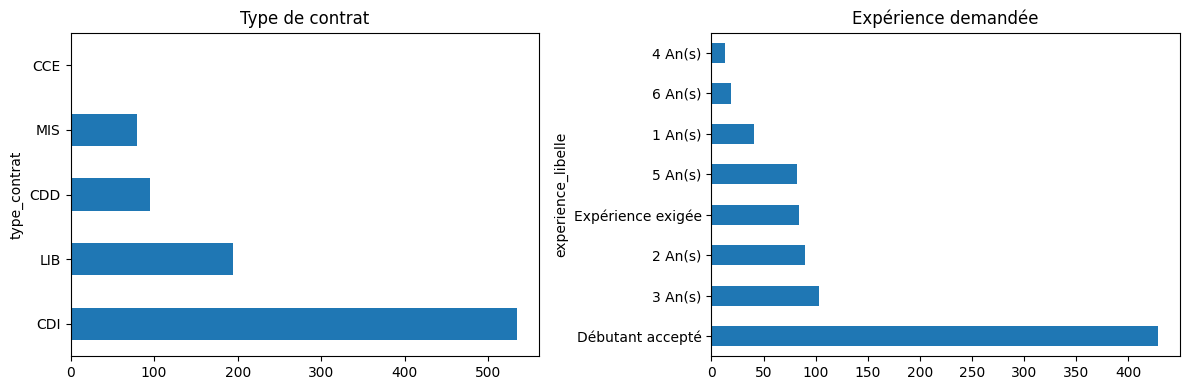

In [74]:
df["date_creation"] = pd.to_datetime(df["date_creation"], errors="coerce")
print("Période couverte :", df["date_creation"].min().date(), "->", df["date_creation"].max().date())

df["nb_mots"] = df["description"].str.split().str.len()
print(df["nb_mots"].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["type_contrat"].value_counts().plot.barh(ax=axes[0], title="Type de contrat")
df["experience_libelle"].value_counts().head(8).plot.barh(ax=axes[1], title="Expérience demandée")
plt.tight_layout()
plt.show()

### 2.1 Localisation

Le libellé du lieu est du type `44 - NANTES`. On en extrait le département, puis on regroupe en trois zones (Île-de-France, Pays de la Loire, autres régions).

In [75]:
PAYS_DE_LA_LOIRE = {"44", "49", "53", "72", "85"}
ILE_DE_FRANCE = {"75", "77", "78", "91", "92", "93", "94", "95"}

def extraire_departement(ligne):
    m = re.match(r"^\s*(\d{2,3}|2[AB])\s*-", str(ligne["lieu"]))
    if m:
        return m.group(1)
    cp = str(ligne["code_postal"])
    return cp[:2] if cp[:2].isdigit() else None

def zone(dep):
    if dep in PAYS_DE_LA_LOIRE:
        return "Pays de la Loire"
    if dep in ILE_DE_FRANCE:
        return "Île-de-France"
    return "Autres régions"

df["departement"] = df.apply(extraire_departement, axis=1)
df["zone"] = df["departement"].apply(zone)
df["zone"].value_counts()


,count
zone,
Île-de-France,497
Autres régions,382
Pays de la Loire,25


### 2.2 Étiqueter le métier à partir de l'intitulé

Les mots-clés de recherche ne suffisent pas : « data analyst » remonte aussi des offres de Data Engineer qui mentionnent les analystes. On définit donc le métier à partir de **l'intitulé du poste** :

- un seul métier reconnu → étiquette retenue ;
- aucun métier reconnu → `Autre` (exclu) ;
- plusieurs métiers (« Data Analyst / Data Scientist ») → `Mixte` (exclu).

Ces règles sont un choix : il faut contrôler un échantillon à la main.

In [92]:
REGLES_METIER = {
    "Data Analyst":   r"data\s*-?\s*analy(?!tics)|analyste\s+(de\s+)?(donn[ée]es|data|bi\b)"
                      r"|analyste\s+d[ée]cisionnel|\bbi\s+analyst|business\s+intelligence\s+analyst",
    "Data Engineer":  r"data\s*-?\s*engineer|analytics\s+engineer"
                      r"|ing[ée]nieure?\s+(de\s+)?(donn[ée]es|data|big\s*data)(?!\s*-?\s*(analy|scien))",
    "Data Scientist": r"data\s*-?\s*scien|scientifique\s+des\s+donn[ée]es|machine\s+learning\s+engineer|ml\s+engineer",
}

def etiqueter(intitule):
    intitule = str(intitule).lower()
    trouves = [metier for metier, motif in REGLES_METIER.items() if re.search(motif, intitule)]
    if len(trouves) == 1:
        return trouves[0]
    return "Mixte" if trouves else "Autre"

df["metier"] = df["intitule"].apply(etiqueter)
print(df["metier"].value_counts())

metier
Data Engineer     190
Data Analyst      152
Data Scientist    101
Name: count, dtype: int64


In [77]:
tmp = (df_brut.drop_duplicates("id")
              .dropna(subset=["description"])
              .drop_duplicates("description")
              .copy())
tmp["metier"] = tmp["intitule"].apply(etiqueter)
print(tmp["metier"].value_counts(), "\n")

print("--- Titres 'Autre' les plus fréquents")
print(tmp.loc[tmp["metier"] == "Autre", "intitule"].str.lower().value_counts().head(30))
print("\n--- Exemples 'Mixte'")
print(tmp.loc[tmp["metier"] == "Mixte", "intitule"].head(10).to_string())

metier
Autre             456
Data Engineer     190
Data Analyst      152
Data Scientist    101
Mixte               5
Name: count, dtype: int64 

--- Titres 'Autre' les plus fréquents
intitule
data manager (h/f)                                                                  32
développeur / développeuse décisionnel - business intelligence (h/f)                 5
ingénieur en renseignement tactique et analyse de données géospatiales (h/f)         4
chef de projet data (h/f)                                                            4
business analyst (h/f)                                                               3
responsable data (h/f)                                                               2
data governance manager (h/f)                                                        2
moex second œuvre - projets data centers (h/f)                                       2
support data h/f                                                                     2
chef de projet data h/f  

**Pourquoi exclure les offres « Mixte » ?**

Les 5 offres classées « Mixte » ont un intitulé qui combine explicitement deux métiers :

| Intitulé | Métiers détectés |
|---|---|
| Data Analyst / Consultante Data Engineer | Data Analyst + Data Engineer |
| Data Analyst / Analytics Engineer Full Stack - GenAI | Data Analyst + Data Engineer |
| Data Scientist / Data Analyst Senior (Retail Food) | Data Scientist + Data Analyst |
| DATA ANALYST / DATA SCIENTIST | Data Analyst + Data Scientist |
| Ingénieur Data & Software / Data Scientist Trade Finance | Data Engineer + Data Scientist |

Ces offres sont exclues de l'analyse pour deux raisons :
- **Questions 1 et 2** : les inclure brouillerait la comparaison entre métiers, puisque leurs compétences relèvent de deux profils à la fois.
- **Question 4** : le modèle de classification a besoin d'une étiquette unique par offre ; un poste hybride n'a pas de « bonne réponse ».

L'impact sur l'échantillon est négligeable (5 offres sur 904). Ces intitulés montrent toutefois que certaines entreprises définissent encore des postes à la frontière de plusieurs métiers.

In [93]:
# Contrôle manuel : quelques intitulés par étiquette
for metier in ["Data Analyst", "Data Engineer", "Data Scientist", "Autre"]:
    print(f"--- {metier}")
    print(df.loc[df["metier"] == metier, "intitule"].head(6).to_string(), "\n")

--- Data Analyst
1    Consultant Data Analyst, Business Intelligence, IA & Data (H/F)
2                                        Data Analyst Power BI (H/F)
3                                           Data Analyst (h/f) (H/F)
5     Consultant Business Intelligence / Data Analyst- Finance (H/F)
6                   Data Analyst expérimenté - CDI - Lille F/H (H/F)
7                                         Digital Data Analyst (H/F) 

--- Data Engineer
195                   Data engineer (H/F)
196       Data Engineer - Freelance (H/F)
201           Data Engineer F/H - ENTORIA
232    (ALTERNANCE) - Data Engineer (H/F)
310                   Data Engineer (H/F)
397         Data Engineer Snowflake (H/F) 

--- Data Scientist
148                                  DATA SCIENTIST ET ANALYST CONFIRMÉ F/H
193              Data Scientist - Expérimenté - Marseille - Freelance (H/F)
379                 Data Scientist & Analytics Specialist - Freelance (H/F)
399                                      Data Sc

In [94]:
METIERS = ["Data Analyst", "Data Engineer", "Data Scientist"]
df = df[df["metier"].isin(METIERS)].copy()
print("Offres retenues pour l'analyse :", len(df))
pd.crosstab(df["zone"], df["metier"], margins=True)

Offres retenues pour l'analyse : 443


metier,Data Analyst,Data Engineer,Data Scientist,All
zone,,,,
Autres régions,63,81,37,181
Pays de la Loire,2,5,3,10
Île-de-France,87,104,61,252
All,152,190,101,443


### Bilan de la préparation : de 1 163 lignes à 443 offres analysées

| Étape | Opération | Offres restantes |
|---|---|---|
| Collecte | 7 mots-clés interrogés via l'API France Travail (04/10/2026) | 1 163 lignes |
| Dédoublonnage `id` | Une même offre remonte via plusieurs mots-clés (−221) | 942 |
| Dédoublonnage description | Même annonce republiée sous un autre `id` (−38) | 904 |
| Étiquetage par l'intitulé | Exclusion des intitulés hors périmètre « Autre » (−456) et des postes hybrides « Mixte » (−5) | **443** |

**Répartition finale** : 152 Data Analyst · 190 Data Engineer · 101 Data Scientist.

**Points d'attention**
- L'API recherche les mots-clés dans tout le texte de l'offre, pas seulement dans l'intitulé : près de la moitié des offres collectées concernent d'autres métiers (Data Manager, Business Analyst, chef de projet data…) et sont exclues.
- Les règles d'étiquetage ont été corrigées après contrôle manuel : orthographe sans accent (« donnees »), intitulés « Ingénieur Data Analyst / Data Scientist », « Data Analytics Engineer ».
- Les offres Data Engineer sont plus nombreuses que les offres Data Analyst sur France Travail à cette date.
- Environ 57 % des offres sont situées en Île-de-France ; les Pays de la Loire ne comptent que 10 offres (dont 2 Data Analyst), trop peu pour une comparaison fiable.

In [95]:
df["zone_q3"] = np.where(df["zone"] == "Île-de-France", "Île-de-France", "Hors Île-de-France")
pd.crosstab(df["zone_q3"], df["metier"], margins=True)

metier,Data Analyst,Data Engineer,Data Scientist,All
zone_q3,,,,
Hors Île-de-France,65,86,40,191
Île-de-France,87,104,61,252
All,152,190,101,443


**Regroupement géographique pour la question 3**

Avec seulement 10 offres en Pays de la Loire (dont 2 Data Analyst), une comparaison régionale fine n'est pas significative. La question 3 compare donc l'**Île-de-France** au **reste de la France** :

| Zone | Data Analyst | Data Engineer | Data Scientist | Total |
|---|---|---|---|---|
| Île-de-France | 87 | 104 | 61 | 252 |
| Hors Île-de-France | 65 | 86 | 40 | 191 |
| **Total** | **152** | **190** | **101** | **443** |

L'Île-de-France concentre environ 57 % des offres, et cette part est similaire pour les trois métiers. Les effectifs des deux zones (87 et 65 offres Data Analyst) sont suffisants pour comparer les compétences demandées.

La collecte quotidienne prévue en V2 permettra d'accumuler assez d'offres pour analyser spécifiquement le marché nantais.

## 3. Extraction des compétences (dictionnaire)

Pour répondre aux questions 1, 3 et 5, une approche par **dictionnaire d'expressions régulières** est plus fiable et plus lisible qu'une liste de mots fréquents : « Power BI » reste un seul outil, et on compte **la part des offres** qui citent chaque compétence (et non le nombre d'occurrences).

⚠️ Pièges du français à gérer dans les motifs :
- `tableau` (l'outil) vs « tableau de bord » ;
- `SAS` (le logiciel) vs « SAS au capital de… » (forme juridique) ;
- `R` (le langage) vs une lettre isolée.

À enrichir après lecture d'un échantillon d'offres.

In [138]:
COMPETENCES = {
    # Langages
    "SQL":              r"\bsql\b",
    "Python":           r"\bpython\b",
    "R":                r"\blangage\s+r\b|\brstudio\b|(?<![\w&'-])r(?=\s*[,/)])",
    "SAS":              r"\bsas\b(?!\s*(au\s+capital|unipersonnelle|,?\s*soci))",
    "VBA":              r"\bvba\b",
    # Visualisation / BI
    "Power BI":         r"power\s*-?\s*bi\b",
    "Tableau":          r"\btableau\b(?!\s+(de|des|du|d['’]|récapitulatif|croisé|excel))",
    "Excel":            r"\bexcel\b",
    "Looker":           r"\blooker\b",
    "Qlik":             r"\bqlik",
    # Data engineering / cloud
    "dbt":              r"\bdbt\b",
    "Spark":            r"\bspark\b",
    "Airflow":          r"\bairflow\b",
    "ETL":              r"\betl\b|\belt\b",
    "Snowflake":        r"\bsnowflake\b",
    "BigQuery":         r"big\s*query",
    "Databricks":       r"\bdatabricks\b",
    "Azure":            r"\bazure\b",
    "AWS":              r"\baws\b|amazon\s+web\s+services",
    "GCP":              r"\bgcp\b|google\s+cloud",
    "Git":              r"\bgit\b|github|gitlab",
    "Docker":           r"\bdocker\b",
    "CI/CD":            r"\bci\s*[/-]?\s*cd\b|int[ée]gration\s+continue|d[ée]ploiement\s+continu",
    # Data science
    "Statistiques":     r"statisti",
    "Machine learning": r"machine\s+learning|apprentissage\s+automatique",
    "Deep learning":    r"deep\s+learning|tensorflow|pytorch|keras",
    "IA générative":    r"\bia\s+g[ée]n[ée]rative|intelligence\s+artificielle\s+g[ée]n[ée]rative"
                        r"|\bgen\s*-?\s*ai\b|generative\s+ai|\bllms?\b|\brag\b|large\s+language\s+models?",
    # Métier / transverse
    "SAP":              r"\bsap\b",
    "Supply chain":     r"supply\s*chain|logistique|approvisionnement",
    "Anglais":          r"\banglais\b|\benglish\b",
    "Agile / Scrum":    r"\bagile\b|\bscrum\b",
    "Storytelling":     r"storytelling|vulgaris|pédagog",
}

texte_min = (df["intitule"].fillna("") + " " + df["description"]).str.lower()
for nom, motif in COMPETENCES.items():
    df[f"comp_{nom}"] = texte_min.apply(lambda texte: re.search(motif, texte) is not None)

COLS_COMP = [f"comp_{nom}" for nom in COMPETENCES]

In [165]:
# Contrôle qualité des motifs : afficher le contexte de quelques détections
def contexte(nom, n=5, largeur=60):
    motif = COMPETENCES[nom]
    for texte in texte_min[df[f"comp_{nom}"]].head(n):
        m = re.search(motif, texte)
        print("…" + texte[max(0, m.start() - largeur): m.end() + largeur].replace("\n", " ") + "…")

contexte("Tableau")

…  compétences : business intelligence : power bi, qlikview, tableau, reporting, dashboard décisionnels analyse de données : sql…
…es bonnes décisions ?  tu maîtrises sql, dbt, databricks et tableau et tu veux intervenir sur des sujets data à fort impact bus…
…e de google analytics 4 et d'un outil de datavisualisation (tableau, looker studio). maîtrise de sql et expérience dans l'utili…
…de bord avec des outils de reporting et data visualisation (tableau, business objects), l'accompagnement des équipes de réalisa…
… comme snowflake et outils de data visualisation (power bi, tableau).  - compétences en intégration et gestion de données (sql,…


In [167]:
contexte("Tableau", n=15)
print("\n--- SAS")
contexte("SAS", n=10)
print("\n--- R")
contexte("R", n=10)

# Contrôle des nouveaux motifs
print("--- IA générative")
contexte("IA générative", n=10)
print("\n--- CI/CD")
contexte("CI/CD", n=10)

…  compétences : business intelligence : power bi, qlikview, tableau, reporting, dashboard décisionnels analyse de données : sql…
…es bonnes décisions ?  tu maîtrises sql, dbt, databricks et tableau et tu veux intervenir sur des sujets data à fort impact bus…
…e de google analytics 4 et d'un outil de datavisualisation (tableau, looker studio). maîtrise de sql et expérience dans l'utili…
…de bord avec des outils de reporting et data visualisation (tableau, business objects), l'accompagnement des équipes de réalisa…
… comme snowflake et outils de data visualisation (power bi, tableau).  - compétences en intégration et gestion de données (sql,…
…echniques : maîtrise des outils de visualisation (power bi, tableau), excel avancé, gestion des bases de données et excellente …
…données ; sql ; un outil de visualisation tel que power bi, tableau ou looker studio ; la manipulation et l'analyse de données.…
… et ci/cd.   *      compétences en data visualisation, avec tableau ou un outil équivalen

**Contrôle qualité des motifs ambigus**

Vérification manuelle du contexte de chaque détection sur un échantillon (15 offres pour Tableau, 10 pour SAS et R) : toutes les occurrences correspondent bien à l'outil recherché (Tableau cité parmi les outils de BI, SAS en tant que logiciel, R en tant que langage). Les exclusions prévues dans les motifs (« tableau de bord », « tableau croisé », « SAS au capital ») fonctionnent.

À noter : plusieurs offres mentionnant SAS décrivent une **migration de SAS vers Python / PySpark**, signe d'un outil en perte de vitesse au profit de l'écosystème Python.

**Nouveaux motifs ajoutés après l'exploration TF-IDF (partie 5)** : les termes distinctifs ont révélé deux compétences absentes de la première version du dictionnaire, ajoutées ici :
- « IA générative » (IA générative, GenAI, LLM, RAG) ;
- « CI/CD » (intégration et déploiement continus).

Contrôle manuel sur 10 détections chacun : toutes les occurrences sont pertinentes. L'IA générative apparaît même dans quelques offres Data Analyst (3 %), pour automatiser le reporting ou aider à interpréter les résultats.

### 3.1 Question 1 — Compétences les plus demandées pour un Data Analyst

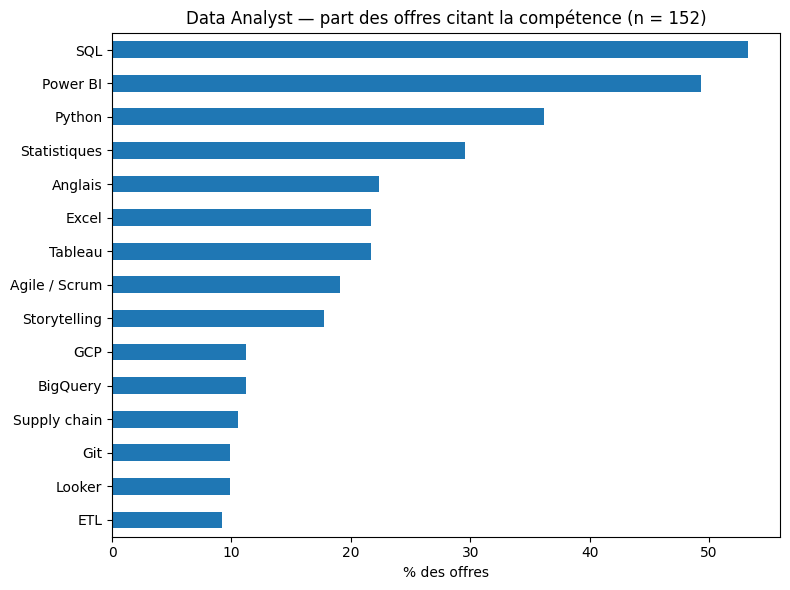

In [168]:
def taux_competences(sous_df):
    return (sous_df[COLS_COMP].mean() * 100).rename(lambda c: c.replace("comp_", ""))

taux_da = taux_competences(df[df["metier"] == "Data Analyst"]).sort_values()

ax = taux_da.tail(15).plot.barh(figsize=(8, 6))
ax.set_title(f"Data Analyst — part des offres citant la compétence (n = {(df['metier'] == 'Data Analyst').sum()})")
ax.set_xlabel("% des offres")
plt.tight_layout()
plt.show()

In [169]:
taux_da.sort_values(ascending=False).round(1).head(15)

,0
SQL,53.3
Power BI,49.3
Python,36.2
Statistiques,29.6
Anglais,22.4
Tableau,21.7
Excel,21.7
Agile / Scrum,19.1
Storytelling,17.8
BigQuery,11.2


**Réponse Q1** : sur 152 offres Data Analyst, le socle attendu est clair.

- **SQL (53,3 %) et Power BI (49,3 %)** dominent nettement : ce sont les deux compétences de base du métier, citées dans environ une offre sur deux.
- **Python (36,2 %)** et les **statistiques (29,6 %)** suivent : appréciés, mais pas systématiquement exigés.
- **Power BI est cité plus de deux fois plus souvent que Tableau** (49,3 % contre 21,7 %) : c'est l'outil de BI de référence sur le marché français.
- Les compétences transverses comptent : anglais (22,4 %), méthodes agiles (19,1 %) et capacité à vulgariser / storytelling (17,8 %).
- Les compétences cloud (GCP, BigQuery : 11,2 %) et engineering (Git 9,9 %, ETL 9,2 %) restent minoritaires chez le Data Analyst.
- Le domaine supply chain apparaît dans 10,5 % des offres : une connaissance métier qui peut faire la différence.

⚠️ Ces taux sont des minimums : une compétence considérée comme implicite (ex. Excel, 21,7 %) n'est pas toujours écrite dans l'offre.

### 3.2 Question 2 — Comparaison des trois métiers

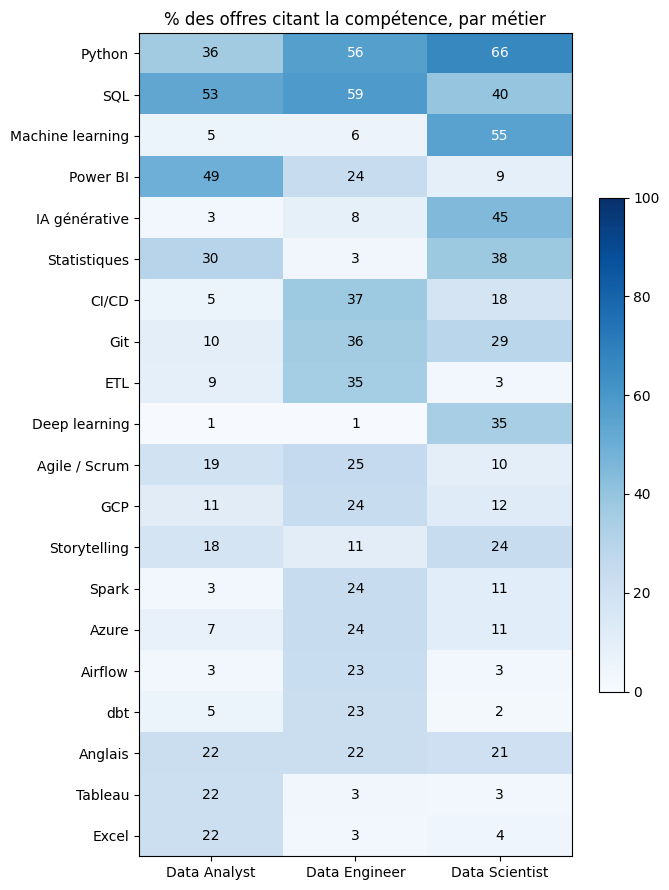

In [170]:
taux_par_metier = pd.DataFrame({m: taux_competences(df[df["metier"] == m]) for m in METIERS})
top = taux_par_metier.max(axis=1).sort_values(ascending=False).head(20).index
matrice = taux_par_metier.loc[top]

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(matrice.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(METIERS)), METIERS)
ax.set_yticks(range(len(top)), top)
for i in range(matrice.shape[0]):
    for j in range(matrice.shape[1]):
        v = matrice.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", color="white" if v > 55 else "black")
ax.set_title("% des offres citant la compétence, par métier")
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

**Réponse Q2** : les trois métiers partagent un socle commun mais se distinguent nettement par leurs outils.

- **Socle commun** : SQL est demandé dans tous les métiers (53 % DA, 59 % DE, 40 % DS), et l'anglais à un niveau similaire (≈ 22 %). Python est également présent partout, mais avec un net gradient : 36 % pour les Data Analysts, 56 % pour les Data Engineers et 66 % pour les Data Scientists.
- **Data Analyst — restitution et BI** : Power BI (49 %), Excel (22 %) et Tableau (22 %) sont quasi exclusifs à ce métier (≤ 24 % ailleurs pour Power BI, ≤ 4 % pour Excel et Tableau).
- **Data Engineer — infrastructure et cloud** : CI/CD (37 %), Git (36 %), ETL (35 %) et toute une pile d'outils (Azure, GCP, Spark, Airflow, dbt, Databricks, Snowflake : 21 à 24 % chacun), presque absents des offres Data Analyst.
- **Data Scientist — modélisation et IA** : Python (66 %), machine learning (55 %), **IA générative (45 %)**, statistiques (38 %) et deep learning (35 %). L'IA générative (LLM, RAG) est déjà citée dans près d'une offre Data Scientist sur deux, alors qu'elle reste marginale pour les Data Analysts (3 %).

Deux observations moins attendues : les statistiques sont quasiment absentes des offres Data Engineer (3 %), et le storytelling est plus souvent cité pour les Data Scientists (24 %) que pour les Data Analysts (18 %), signe que l'explication des modèles aux métiers est aussi un enjeu.

### 3.3 Question 3 — Île-de-France vs reste de la France (Data Analyst)

⚠️ Vérifier l'effectif de chaque zone avant de conclure : un écart de 10 points sur 30 offres n'est pas significatif.

zone_q3
Île-de-France         87
Hors Île-de-France    65
Name: count, dtype: int64


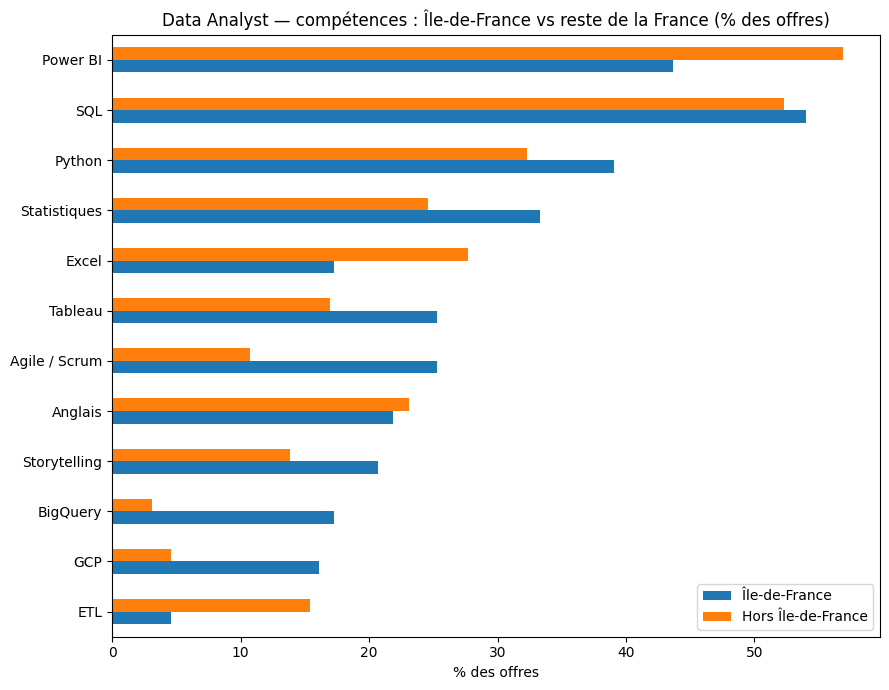

In [144]:
da = df[df["metier"] == "Data Analyst"]
effectifs = da["zone_q3"].value_counts()
print(effectifs)

taux_zone = pd.DataFrame({z: taux_competences(da[da["zone_q3"] == z]) for z in effectifs.index})
taux_zone = taux_zone.loc[taux_zone.max(axis=1).sort_values(ascending=False).head(12).index]

ax = taux_zone.iloc[::-1].plot.barh(figsize=(9, 7))
ax.set_title("Data Analyst — compétences : Île-de-France vs reste de la France (% des offres)")
ax.set_xlabel("% des offres")
plt.tight_layout()
plt.show()

In [145]:
taux_zone_complet = pd.DataFrame({z: taux_competences(da[da["zone_q3"] == z]) for z in effectifs.index})
taux_zone_complet.loc[["GCP", "BigQuery", "Azure", "AWS"]].round(1)

,Île-de-France,Hors Île-de-France
GCP,16.1,4.6
BigQuery,17.2,3.1
Azure,8.0,6.2
AWS,3.4,1.5


In [146]:
masque = (da["zone_q3"] == "Île-de-France") & da["comp_BigQuery"]
da.loc[masque, "entreprise"].value_counts(dropna=False)

,count
entreprise,
Collective.work,6
NaN,3
DGTL Performance,2
Act Digital France,1
LABORATOIRES DE BIOLOGIE VEGETALE YVES R,1
IONIS Group,1
NEW NET 3D,1


In [147]:
da["entreprise"].value_counts(dropna=False).head(10)

,count
entreprise,
NaN,36
Collective.work,32
ISCOD,5
JEMS,4
NEW NET 3D,3
MICHAEL PAGE ADVERTISING,2
POK,2
CRIT INTERIM,2
DGTL Performance,2


In [148]:
sans_cw = da[da["entreprise"] != "Collective.work"]
cw = da[da["entreprise"] == "Collective.work"]

comparaison = pd.DataFrame({
    f"Tous (n={len(da)})": taux_competences(da),
    f"Sans Collective.work (n={len(sans_cw)})": taux_competences(sans_cw),
    f"Collective.work seul (n={len(cw)})": taux_competences(cw),
}).round(1)
comparaison.sort_values(comparaison.columns[0], ascending=False).head(15)

,Tous (n=152),Sans Collective.work (n=120),Collective.work seul (n=32)
SQL,53.3,50.8,62.5
Power BI,49.3,50.8,43.8
Python,36.2,34.2,43.8
Statistiques,29.6,29.2,31.2
Anglais,22.4,22.5,21.9
Tableau,21.7,20.0,28.1
Excel,21.7,25.0,9.4
Agile / Scrum,19.1,17.5,25.0
Storytelling,17.8,16.7,21.9
BigQuery,11.2,9.2,18.8


**Analyse de sensibilité : effet d'un émetteur dominant**

Un même émetteur, Collective.work, publie 32 des 152 offres Data Analyst (21 %). Pour vérifier qu'il ne biaise pas les résultats, les taux ont été recalculés sans ses offres :

- **Le socle reste identique** : SQL (50,8 %), Power BI (50,8 %), Python (34,2 %), statistiques (29,2 %) et anglais (22,5 %) varient de moins de 3 points. Les conclusions de la question 1 sont donc robustes.
- **Les compétences cloud et engineering sont en revanche gonflées par cet émetteur**, dont les offres sont plus techniques : GCP (28,1 % chez Collective.work contre 6,7 % ailleurs), Git (21,9 % contre 6,7 %), Looker (21,9 % contre 6,7 %), BigQuery (18,8 % contre 9,2 %).
- Sans Collective.work, Excel (25,0 %) devance Tableau (20,0 %).

Conséquence pour la question 3 : l'avance de l'Île-de-France sur l'écosystème Google s'explique en partie par cet émetteur et doit être interprétée avec prudence.

**Réponse Q3** : comparaison des 87 offres Data Analyst en Île-de-France et des 65 offres hors Île-de-France.

- **Socle identique** : SQL (≈ 53 %) et l'anglais (≈ 22 %) sont demandés dans les mêmes proportions dans les deux zones.
- **En Île-de-France**, les offres citent plus souvent un environnement cloud et des méthodes agiles : BigQuery (≈ 17 % contre ≈ 3 %), GCP (≈ 16 % contre ≈ 5 %), Agile / Scrum (≈ 25 % contre ≈ 11 %), ainsi que Python et les statistiques.
- **Hors Île-de-France**, les outils de BI classiques sont plus présents : Power BI (≈ 57 % contre ≈ 44 %) et Excel (≈ 28 % contre ≈ 17 %). L'ETL y apparaît aussi plus souvent (≈ 15 % contre ≈ 5 %), ce qui suggère des postes de Data Analyst plus polyvalents dans des équipes de plus petite taille.

⚠️ Avec 87 et 65 offres, ces écarts sont à lire comme des tendances plutôt que comme des différences statistiquement établies.

### 3.4 Question 5 — Offres accessibles aux débutants (Data Analyst)

In [149]:
# experienceExige : D = débutant accepté, E = expérience exigée, S = expérience souhaitée
da = da.assign(niveau=np.where(da["experience_exige"] == "D", "Débutant accepté", "Expérience demandée"))
print(da["niveau"].value_counts())

taux_niveau = pd.DataFrame({n: taux_competences(da[da["niveau"] == n]) for n in da["niveau"].unique()})
taux_niveau.sort_values(taux_niveau.columns[0], ascending=False).head(12).round(1)

niveau
Expérience demandée    80
Débutant accepté       72
Name: count, dtype: int64


,Expérience demandée,Débutant accepté
SQL,62.5,43.1
Power BI,56.2,41.7
Python,41.2,30.6
Statistiques,35.0,23.6
Excel,26.2,16.7
Tableau,25.0,18.1
Anglais,25.0,19.4
Agile / Scrum,22.5,15.3
Storytelling,22.5,12.5
ETL,12.5,5.6


In [150]:
# 1. Les descriptions des offres « débutant accepté » sont-elles plus courtes ?
print(da.groupby("niveau")["nb_mots"].median(), "\n")

# 2. Parmi les offres « débutant accepté », combien exigent quand même X ans d'expérience dans le texte ?
motif_exp = r"\d+\s*(\+\s*)?ans?\s+(d['’]\s*)?exp[ée]rience"
deb = da[da["niveau"] == "Débutant accepté"]
mention = deb["description"].str.lower().str.contains(motif_exp, regex=True)
print(f"{mention.sum()} offres « débutant accepté » sur {len(deb)} mentionnent pourtant X ans d'expérience\n")

# 3. Répartition des types de contrat selon le niveau d'expérience
pd.crosstab(da["niveau"], da["type_contrat"])

niveau
Débutant accepté       287.0
Expérience demandée    378.0
Name: nb_mots, dtype: float64 

11 offres « débutant accepté » sur 72 mentionnent pourtant X ans d'expérience



/tmp/ipykernel_6440/613365839.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mention = deb["description"].str.lower().str.contains(motif_exp, regex=True)


type_contrat,CDD,CDI,LIB,MIS
niveau,,,,
Débutant accepté,16,32,15,9
Expérience demandée,12,53,10,5


**Réponse Q5** : 72 des 152 offres Data Analyst (47 %) sont marquées « débutant accepté » sur France Travail.

- **Les compétences attendues sont les mêmes** que pour les postes demandant de l'expérience, dans le même ordre : SQL (43,1 %), Power BI (41,7 %), Python (30,6 %) et statistiques (23,6 %).
- **Les offres débutants citent simplement moins de compétences** : chaque taux est plus faible que pour les postes expérimentés (SQL 43,1 % contre 62,5 %, Power BI 41,7 % contre 56,2 %). Leurs descriptions sont aussi plus courtes (287 mots en médiane contre 378).
- Les écarts les plus marqués concernent les compétences de **communication et d'organisation** : storytelling (12,5 % contre 22,5 %) et méthodes agiles (15,3 % contre 22,5 %), ainsi que l'ETL (5,6 % contre 12,5 %), plus attendus avec l'expérience.
- Les compétences cloud (BigQuery 11 %, Git 10 %) sont citées dans les mêmes proportions quel que soit le niveau.
- **Les offres débutants sont moins souvent en CDI** : 32 sur 72 (44 %), contre 53 sur 80 (66 %) pour les postes expérimentés ; les CDD, missions d'intérim et contrats libéraux y sont plus fréquents.

**Pour un profil débutant**, le message est clair : maîtriser **SQL et Power BI** reste la priorité, Python et les statistiques constituant un atout.

⚠️ Le champ « débutant accepté » est renseigné par le recruteur et peut être coché par défaut : **11 de ces 72 offres** mentionnent malgré tout un nombre d'années d'expérience dans leur description.

## 4. Préparation du texte pour le NLP

1. **Masquer les noms de métier** dans la description : sinon le modèle de la partie 6 apprendrait simplement que « analyst » ⇒ Data Analyst (fuite de la cible).
2. **Lemmatiser en français avec spaCy** (`fr_core_news_sm`) : le stemming est moins adapté au français, très flexionnel (« analyses », « analysé », « analyser » → « analyser »).
3. **Stopwords adaptés** : stopwords NLTK français + vocabulaire générique des annonces (« poste », « mission », « profil »…), qui n'aide ni l'exploration ni la classification. On **conserve** `pas`, `ne`, `sans`.

In [175]:
MOTIF_METIER = (r"data\s*-?\s*(analysts?|analystes?|engineer(?:s|ing)?|scientists?)"
                r"|\b(analysts?|analystes?|engineer(?:s|ing)?|scientists?|ing[ée]nieure?s?|scientifiques?)\b")

def masquer_metier(texte):
    return re.sub(MOTIF_METIER, " ", str(texte), flags=re.IGNORECASE)

df["description_masquee"] = df["description"].apply(masquer_metier)
df[["description", "description_masquee"]].head(2)

,description,description_masquee
1,Recherche un(une) Data Analyst / Business Intelligence / SQL & Power BI / IA appliquée à la Data pour les tâches sui...,Recherche un(une) / Business Intelligence / SQL & Power BI / IA appliquée à la Data pour les tâches suivantes :\n\...
2,"Présentation de l'entreprise:\n\nDepuis 1993, le Groupe YRCAM accompagne PME et grandes entreprises dans l'optimisat...","Présentation de l'entreprise:\n\nDepuis 1993, le Groupe YRCAM accompagne PME et grandes entreprises dans l'optimisat..."


In [176]:
# Vérification : reste-t-il des noms de métier après masquage ?
reste = df["description_masquee"].str.contains(r"analyst|engineer|scientist", case=False)
print(f"{reste.sum()} descriptions contiennent encore un nom de métier")

1 descriptions contiennent encore un nom de métier


In [177]:
# Quels mots contenant un nom de métier subsistent après masquage ?
mots = df["description_masquee"].str.findall(r"\w*(?:analyst|engineer|scientist)\w*", flags=re.IGNORECASE)
pd.Series([m.lower() for liste in mots for m in liste]).value_counts()

,count
engineeringcollaboration,1


In [ ]:
# Colab : télécharger le modèle français de spaCy à chaque nouvelle session
# !python -m spacy download fr_core_news_sm

In [178]:
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

GARDER = {"pas", "ne", "sans"}
STOPWORDS_ANNONCES = {
    "poste", "postes", "mission", "missions", "profil", "candidat", "candidature", "entreprise",
    "équipe", "client", "clients", "société", "groupe", "rejoindre", "recherche", "rechercher",
    "sein", "cadre", "h", "f", "cdi", "cdd", "an", "année", "ans", "être", "avoir", "faire",
    "pouvoir", "devoir", "aussi", "ainsi", "afin", "notamment", "etc", "www", "http", "https", "com",
    "sous", "chez", "vers", "dont", "plus", "très", "tout", "tous", "toute", "toutes", "bien",
}
STOPWORDS_FR = (set(stopwords.words("french")) | STOPWORDS_ANNONCES) - GARDER

# Le petit modèle spaCy « lemmatise » mal les noms d'outils (aws -> aw, azure -> azur,
# databricks -> databrick) : on les garde tels quels.
TERMES_TECH = {
    "aws", "azure", "gcp", "databricks", "snowflake", "bigquery", "sas", "sap", "dbt", "spark",
    "airflow", "pandas", "kubernetes", "docker", "git", "github", "gitlab", "looker", "qlik",
    "excel", "vba", "python", "sql", "nosql", "tableau", "power", "bi", "etl", "elt",
    # Mots anglais mal lemmatisés par le modèle français (data -> dater)
    "data", "business", "cloud", "pipeline", "machine", "learning", "dashboard", "reporting",
}

def lemmatiser(docs):
    """Renvoie une liste de lemmes par document (nlp.pipe = traitement par lots, plus rapide)."""
    resultats = []
    for doc in nlp.pipe(docs, batch_size=50):
        lemmes = []
        for tok in doc:
            mot = tok.lower_
            if not tok.is_alpha or mot in STOPWORDS_FR:
                continue
            lemme = mot if mot in TERMES_TECH else tok.lemma_.lower()
            if len(lemme) > 1 and lemme not in STOPWORDS_FR:
                lemmes.append(lemme)
        resultats.append(lemmes)
    return resultats

df["lemmes"] = lemmatiser(df["description_masquee"].str.lower())
df["texte_lemmatise"] = df["lemmes"].str.join(" ")
df[["intitule", "texte_lemmatise"]].head()

,intitule,texte_lemmatise
1,"Consultant Data Analyst, Business Intelligence, IA & Data (H/F)",business intelligence sql power bi ia appliquer data tâche suivant analyse donnée transactionnel suivre kpi opératio...
2,Data Analyst Power BI (H/F),présentation depuis yrcam accompagner pm grand optimisation trésorerie côté prestigieux comme airbus apav sodexo pwc...
3,Data Analyst (h/f) (H/F),agence adecco lyon tertiaire baser lyon finance principal assurer suivi fiabilité reporting financier contrôler qual...
5,Consultant Business Intelligence / Data Analyst- Finance (H/F),souhaiter exercer fonction consulter business intelligence finance contrôle gestion statut sans liste ne exhaustive ...
6,Data Analyst expérimenté - CDI - Lille F/H (H/F),aimer transformer donnée complexe insight concret aider prendre bon décision maîtrise sql dbt databricks tableau veu...


**Résultat de la préparation** : chaque description est réduite à ses mots porteurs de sens, ramenés à leur forme de base (ex. « J'aime transformer des données complexes en insights concrets » → « aimer transformer donnée complexe insight concret »).

Deux limites observées :
- Le modèle spaCy français lemmatise mal certains termes anglais (« data » devenait « dater ») : ils ont été ajoutés à la liste `TERMES_TECH` pour être conservés tels quels.
- La présentation de l'entreprise en début d'annonce introduit du bruit (noms d'entreprises, de villes : *airbus, sodexo, adecco, lyon*…). Le paramètre `min_df=5` de la partie 5 écarte la plupart de ces termes rares.

## 5. Exploration lexicale : WordClouds et TF-IDF

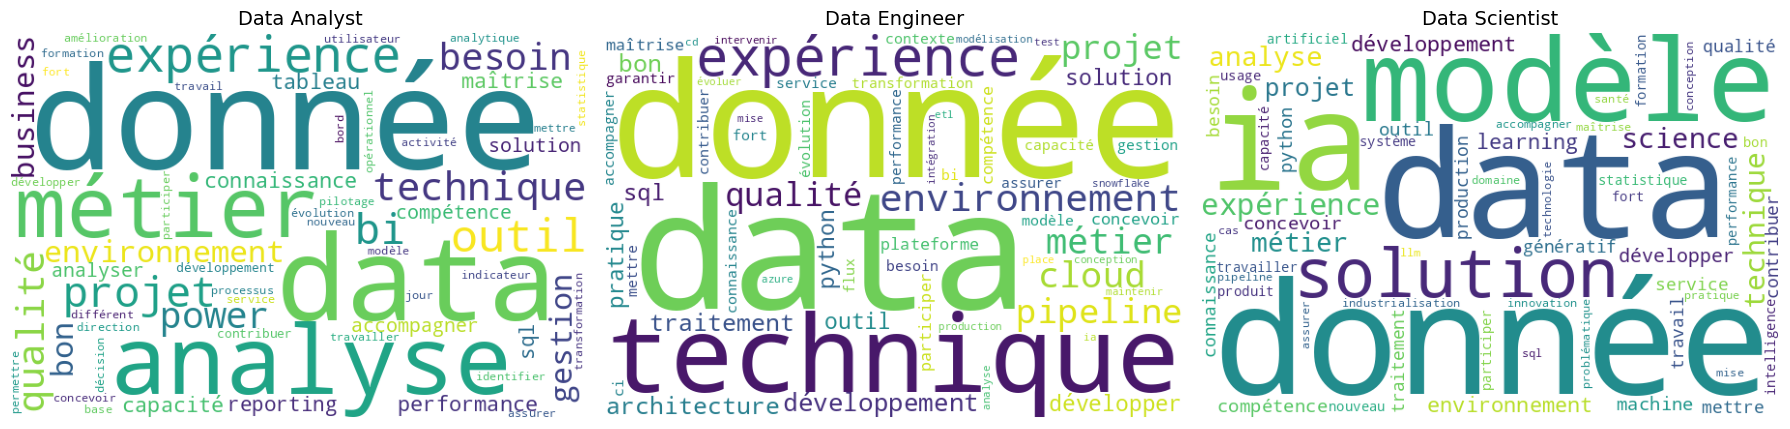

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metier in zip(axes, METIERS):
    freq = pd.Series([l for liste in df.loc[df["metier"] == metier, "lemmes"] for l in liste]).value_counts()
    nuage = WordCloud(width=600, height=400, background_color="white", max_words=60)
    ax.imshow(nuage.generate_from_frequencies(freq.to_dict()))
    ax.set_title(metier, fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()

Après correction de la lemmatisation (« data » était transformé en « dater » par le modèle spaCy français), les WordClouds font apparaître des univers distincts : **analyse, métier, business, BI, reporting** pour le Data Analyst ; **pipeline, cloud, architecture, plateforme** pour le Data Engineer ; **modèle, IA, machine learning, génératif** pour le Data Scientist. Les mots les plus visibles (donnée, data, expérience) restent toutefois communs aux trois métiers.

Les WordClouds montrent surtout les mots **communs** aux trois métiers (« donnée », « outil », « analyse »…). Pour faire ressortir ce qui **distingue** chaque métier, on compare le **poids TF-IDF moyen** d'un terme dans le métier à son poids moyen dans les deux autres.

In [181]:
tfidf_explo = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.7)
M = tfidf_explo.fit_transform(df["texte_lemmatise"])
termes = tfidf_explo.get_feature_names_out()

distinctifs = {}
for metier in METIERS:
    masque = (df["metier"] == metier).values
    ecart = np.asarray(M[masque].mean(axis=0)).ravel() - np.asarray(M[~masque].mean(axis=0)).ravel()
    distinctifs[metier] = termes[ecart.argsort()[::-1][:15]]

pd.DataFrame(distinctifs)

,Data Analyst,Data Engineer,Data Scientist
0,analyse,cloud,ia
1,business,pipeline,modèle
2,reporting,architecture,science
3,bi,plateforme,learning
4,tableau,snowflake,data science
5,power,traitement,machine
6,power bi,dbt,machine learning
7,indicateur,ci,génératif
8,bord,pratique,ia génératif
9,tableau bord,azure,intelligence artificiel


**Commentaire** : les termes distinctifs TF-IDF confirment le dictionnaire de la partie 3 (Power BI pour le Data Analyst ; Snowflake, dbt, Azure, ETL pour le Data Engineer ; machine learning et deep learning pour le Data Scientist) et précisent la nature de chaque métier :

- **Data Analyst** : orienté **métier et décision** — analyse, business, reporting, tableau de bord, indicateurs, pilotage, marketing.
- **Data Engineer** : orienté **infrastructure** — cloud, pipeline, architecture, plateforme, infrastructure.
- **Data Scientist** : orienté **modélisation et IA** — modèle, machine learning, data science.

Ils font aussi apparaître des compétences **absentes du dictionnaire** : la CI/CD pour le Data Engineer et surtout l'**IA générative (LLM, RAG)** pour le Data Scientist, tendance récente. Ces deux compétences ont donc été ajoutées au dictionnaire de la partie 3.

## 6. Question 4 — Prédire le métier à partir de la description

- Cible : `metier` (3 classes, probablement déséquilibrées → `class_weight="balanced"` et **F1 macro** en plus de l'accuracy).
- Entrée : description lemmatisée **avec les noms de métier masqués**.
- Le `Pipeline` garantit que le vectorizer n'est appris que sur le train (pas de fuite vers le test).

In [183]:
X = df["texte_lemmatise"]
y = df["metier"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.80, random_state=42, stratify=y
)
print("Train :", X_train.shape[0], "| Test :", X_test.shape[0])
print(y_train.value_counts(normalize=True).round(2))

Train : 354 | Test : 89
metier
Data Engineer     0.43
Data Analyst      0.34
Data Scientist    0.23
Name: proportion, dtype: float64


Découpage stratifié 80 / 20 : 354 offres d'entraînement, 89 de test, avec la même répartition des métiers (Data Engineer 43 %, Data Analyst 34 %, Data Scientist 23 %).

**Point de référence** : un modèle naïf prédisant toujours la classe majoritaire (Data Engineer) obtiendrait 43 % d'accuracy. Le modèle doit faire nettement mieux pour être utile.

In [184]:
def evaluer(vectorizer):
    pipe = make_pipeline(vectorizer, LogisticRegression(max_iter=1000, class_weight="balanced"))
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        "accuracy_train": round(pipe.score(X_train, y_train), 3),
        "accuracy_test": round(accuracy_score(y_test, pred), 3),
        "f1_macro_test": round(f1_score(y_test, pred, average="macro"), 3),
    }

configs = {
    "BoW": CountVectorizer(),
    "BoW bigrammes": CountVectorizer(ngram_range=(1, 2), min_df=2),
    "TF-IDF": TfidfVectorizer(),
    "TF-IDF bigrammes": TfidfVectorizer(ngram_range=(1, 2), min_df=2),
}
resultats = pd.DataFrame({nom: evaluer(vec) for nom, vec in configs.items()}).T
resultats.sort_values("f1_macro_test", ascending=False)

,accuracy_train,accuracy_test,f1_macro_test
TF-IDF bigrammes,0.986,0.865,0.863
TF-IDF,0.980,0.865,0.863
BoW bigrammes,1.000,0.809,0.811
BoW,1.000,0.809,0.811


**Comparaison des vectorisations** (régression logistique, 89 offres de test) :

- **TF-IDF obtient les meilleurs résultats** : 86,5 % d'accuracy et un F1 macro de 0,863, contre 80,9 % / 0,811 pour le Bag of Words. La pondération TF-IDF, qui réduit le poids des mots présents partout (« donnée », « expérience »), aide à distinguer les métiers.
- Ces scores sont **très supérieurs au modèle naïf (43 %)** : même sans le nom du métier, la description suffit à le reconnaître dans près de 9 cas sur 10.
- Le F1 macro est proche de l'accuracy : les trois métiers sont bien reconnus, pas seulement la classe majoritaire.
- **Les bigrammes n'apportent rien ici** : les mots isolés suffisent à distinguer les métiers.
- **Sur-apprentissage modéré** : 98 à 100 % sur le train contre 81 à 87 % sur le test, attendu avec seulement 354 offres d'entraînement pour plusieurs milliers de termes. Il est plus faible avec TF-IDF.

⚠️ Avec 89 offres de test, un point d'accuracy correspond à environ une offre : les écarts de quelques points sont à interpréter avec prudence.

                precision    recall  f1-score   support

  Data Analyst       0.78      0.90      0.84        31
 Data Engineer       0.89      0.89      0.89        38
Data Scientist       1.00      0.75      0.86        20

      accuracy                           0.87        89
     macro avg       0.89      0.85      0.86        89
  weighted avg       0.88      0.87      0.87        89



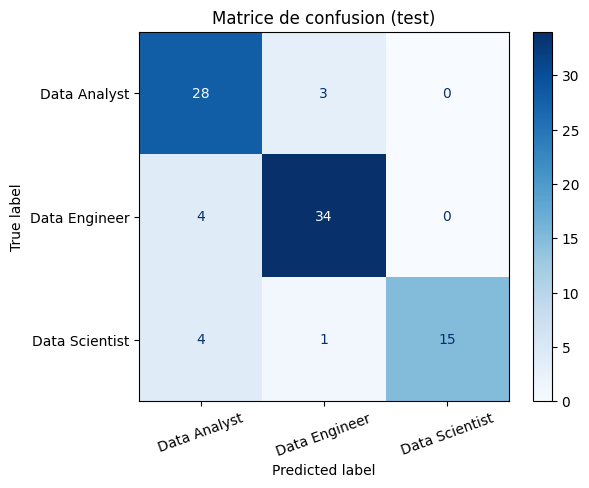

In [186]:
# Modèle retenu : TF-IDF (meilleurs scores dans le tableau ci-dessus)
modele = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
modele.fit(X_train, y_train)
pred = modele.predict(X_test)

print(classification_report(y_test, pred))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues", xticks_rotation=20)
plt.title("Matrice de confusion (test)")
plt.show()

**Modèle retenu : TF-IDF + régression logistique** — 87 % d'accuracy (77 offres sur 89), F1 macro 0,86.

Lecture de la matrice de confusion :
- **Data Analyst et Data Engineer se confondent dans les deux sens** (3 et 4 offres) : ces métiers partagent des compétences (SQL, ETL, qualité des données) et leurs frontières sont parfois floues.
- **Le Data Analyst « attire » les erreurs** : 8 offres d'autres métiers sont prédites Data Analyst, d'où une précision plus faible (0,78). Son vocabulaire (analyse, données, métier, décision) est le plus générique.
- **Le modèle est prudent avec le Data Scientist** : quand il le prédit, il a toujours raison (précision 1,00), mais il manque 5 offres sur 20 (rappel 0,75), principalement classées Data Analyst — probablement des postes plus orientés analyse statistique que machine learning.
- **Data Engineer et Data Scientist ne se confondent quasiment jamais** (1 erreur) : ce sont les deux profils les plus éloignés.

### 6.1 Quels mots « trahissent » chaque métier ?

In [188]:
vec, clf = modele[0], modele[-1]
noms = vec.get_feature_names_out()

mots_par_classe = {
    classe: noms[clf.coef_[i].argsort()[::-1][:15]]
    for i, classe in enumerate(clf.classes_)
}
pd.DataFrame(mots_par_classe)

,Data Analyst,Data Engineer,Data Scientist
0,analyse,cloud,ia
1,business,pipeline,science
2,power,architecture,modèle
3,tableau,plateforme,data science
4,bi,data,learning
5,indicateur,flux,machine
6,power bi,snowflake,machine learning
7,bord,traitement,artificiel
8,analyser,infrastructure,intelligence artificiel
9,tableau bord,pratique,génératif


**Mots qui « trahissent » chaque métier** (coefficients les plus élevés de la régression logistique) :

- **Data Analyst** : analyse, business, métier, Power BI, tableau de bord, dashboard, indicateur, reporting → l'analyse au service des **décisions métier**.
- **Data Engineer** : cloud, pipeline, plateforme, architecture, infrastructure, flux, Snowflake, dbt, Databricks, ETL → la **construction de l'infrastructure de données**.
- **Data Scientist** : IA, modèle, machine learning, IA générative, LLM, GenAI → la **modélisation et l'intelligence artificielle**.

Ces termes recoupent presque exactement les termes distinctifs TF-IDF de la partie 5 : deux méthodes différentes aboutissent au même portrait des trois métiers. Le modèle s'appuie donc sur le **contenu réel des missions** et non sur le nom du poste, masqué en amont.

Deux remarques : « data science », nom du domaine et non du poste, reste un indice très fort pour le Data Scientist ; et « santé » apparaît parmi ses termes caractéristiques, signe d'une présence marquée du secteur de la santé dans les offres Data Scientist.

### 6.2 Analyse des erreurs

In [189]:
erreurs = df.loc[X_test.index].assign(prediction=pred)
erreurs = erreurs[erreurs["metier"] != erreurs["prediction"]]
print(f"{len(erreurs)} offres mal classées sur {len(X_test)}")
erreurs[["intitule", "metier", "prediction"]].head(15)

12 offres mal classées sur 89


,intitule,metier,prediction
16,Data Analyst H/F,Data Analyst,Data Engineer
1060,Data Scientist Confirmé - Mobilité Electrique (F/H),Data Scientist,Data Analyst
462,Data Analytics Engineer - Freelance (H/F),Data Engineer,Data Analyst
201,Data Engineer F/H - ENTORIA,Data Engineer,Data Analyst
1121,Data scientist (H/F),Data Scientist,Data Analyst
902,RESPONSABLE COMPTABILITE ANALYTIQUE ET STRUCTURE / INGENIEUR DATA BI HOSPITALIER - 100% - H/F,Data Engineer,Data Analyst
108,Zenith business data analyst finance (h/f) (H/F),Data Analyst,Data Engineer
1089,ENOVIA Brand Data Scientist (H/F),Data Scientist,Data Analyst
1044,Data scientist (H/F),Data Scientist,Data Engineer
861,Ingénieur Data SAP H/F,Data Engineer,Data Analyst


In [190]:
# Les Data Scientists prédits Data Analyst sont-ils moins orientés machine learning ?
cols = ["comp_Machine learning", "comp_IA générative", "comp_Statistiques", "comp_Power BI", "comp_SQL"]
erreurs.loc[(erreurs["metier"] == "Data Scientist") & (erreurs["prediction"] == "Data Analyst"),
            ["intitule"] + cols]

,intitule,comp_Machine learning,comp_IA générative,comp_Statistiques,comp_Power BI,comp_SQL
1060,Data Scientist Confirmé - Mobilité Electrique (F/H),False,False,False,False,True
1121,Data scientist (H/F),False,False,True,False,False
1089,ENOVIA Brand Data Scientist (H/F),True,False,True,False,True
1049,Data scientist,False,False,False,False,False


**Réponse Q4** : oui, le métier est largement reconnaissable sans son nom. Avec les intitulés de poste masqués, le modèle TF-IDF + régression logistique identifie correctement **87 % des offres** (77 sur 89), contre 43 % pour un modèle naïf.

Les 12 erreurs relèvent de trois cas :
- **Des étiquettes discutables** : « Ingénieur Data BI hospitalier / comptabilité analytique » a été étiqueté Data Engineer par les règles, alors que le modèle le classe Data Analyst, ce qui paraît plus juste au vu des missions.
- **Des postes réellement hybrides** : « Data Analytics Engineer », à la frontière entre analyse et ingénierie, ou « Ingénieur Data SAP ».
- **Des intitulés génériques dont le contenu est peu technique** : sur les 4 offres « Data Scientist » classées Data Analyst, 3 ne mentionnent pas le machine learning (contre 55 % des offres Data Scientist en moyenne) et l'une ne cite aucune compétence du dictionnaire. Faute de signal clair, le modèle se replie sur le Data Analyst, dont le vocabulaire est le plus générique. La seule exception (« Brand Data Scientist ») cite bien le machine learning, mais dans un contexte marketing qui rapproche son vocabulaire de celui du Data Analyst.

Ces erreurs montrent que **les frontières entre métiers sont parfois floues sur le marché**, et que l'intitulé d'une offre ne reflète pas toujours le contenu réel du poste.

In [191]:
# Test sur des descriptions inventées
nouvelles = [
    "Vous construirez des tableaux de bord Power BI et analyserez les ventes avec SQL pour les équipes métier.",
    "Vous développerez des pipelines Airflow et Spark sur Azure et industrialiserez les flux de données.",
    "Vous entraînerez des modèles de machine learning en Python et évaluerez leurs performances.",
]
pd.DataFrame({
    "description": nouvelles,
    "prediction": modele.predict([" ".join(l) for l in lemmatiser([masquer_metier(t).lower() for t in nouvelles])]),
})

,description,prediction
0,Vous construirez des tableaux de bord Power BI et analyserez les ventes avec SQL pour les équipes métier.,Data Analyst
1,Vous développerez des pipelines Airflow et Spark sur Azure et industrialiserez les flux de données.,Data Engineer
2,Vous entraînerez des modèles de machine learning en Python et évaluerez leurs performances.,Data Scientist


**Test sur des descriptions inventées** : les trois descriptions typiques sont correctement classées. Ce test de cohérence confirme que le modèle s'appuie sur les missions (tableaux de bord et analyse métier, pipelines et cloud, modèles de machine learning) pour reconnaître chaque métier.

In [192]:
# Test sur des descriptions ambiguës, avec la probabilité de chaque métier
ambigues = [
    "Vous préparerez les données avec SQL et dbt et construirez des dashboards Power BI.",
    "Vous réaliserez des analyses statistiques et des prévisions des ventes en Python.",
    "Vous intégrerez des solutions d'IA générative dans les outils de reporting.",
]
textes = [" ".join(l) for l in lemmatiser([masquer_metier(t).lower() for t in ambigues])]
probas = pd.DataFrame(modele.predict_proba(textes), columns=modele.classes_).round(2)
probas.insert(0, "description", ambigues)
probas

,description,Data Analyst,Data Engineer,Data Scientist
0,Vous préparerez les données avec SQL et dbt et construirez des dashboards Power BI.,0.58,0.29,0.13
1,Vous réaliserez des analyses statistiques et des prévisions des ventes en Python.,0.47,0.21,0.32
2,Vous intégrerez des solutions d'IA générative dans les outils de reporting.,0.27,0.20,0.53


**Test sur des descriptions ambiguës** : pour des missions à la frontière de deux métiers, le modèle hésite, ce qui est cohérent :

- *SQL, dbt et dashboards Power BI* → Data Analyst (0,58), avec une part notable de Data Engineer (0,29) : un profil typique d'Analytics Engineer.
- *Analyses statistiques et prévisions des ventes en Python* → partagé entre Data Analyst (0,47) et Data Scientist (0,32), comme les offres Data Scientist orientées analyse observées dans l'analyse des erreurs.
- *IA générative intégrée aux outils de reporting* → Data Scientist (0,53), l'IA générative étant un marqueur fort de ce métier, tirée vers le Data Analyst (0,27) par le reporting.

Aucune probabilité ne dépasse 0,6 : sur des postes hybrides, le modèle exprime une incertitude plutôt qu'une réponse tranchée.

## 7. Exports pour le dashboard Power BI

Format **long** (une ligne = métier × compétence), plus pratique dans Power BI qu'un tableau croisé.

In [194]:
def format_long(taux, colonne):
    return (taux.rename_axis("competence").reset_index()
                .melt(id_vars="competence", var_name=colonne, value_name="pct_offres")
                .round(1))

format_long(taux_par_metier, "metier").to_csv(OUT_DIR / "competences_par_metier.csv", index=False)
format_long(
    pd.DataFrame({z: taux_competences(df[(df["metier"] == "Data Analyst") & (df["zone_q3"] == z)])
                  for z in df["zone_q3"].unique()}),
    "zone",
).to_csv(OUT_DIR / "competences_da_par_zone.csv", index=False)

colonnes_export = ["id", "intitule", "entreprise", "metier", "zone", "zone_q3", "departement",
                   "type_contrat", "experience_exige", "experience_libelle", "date_creation"] + COLS_COMP
df[colonnes_export].to_csv(OUT_DIR / "offres_clean.csv", index=False)

print(sorted(p.name for p in OUT_DIR.glob("*.csv")))

['competences_da_par_zone.csv', 'competences_par_metier.csv', 'offres_clean.csv']


In [ ]:
# Colab uniquement : télécharger les exports (les fichiers Colab sont supprimés en fin de session)
# import shutil
# from google.colab import files
# shutil.make_archive("exports_powerbi", "zip", OUT_DIR)
# files.download("exports_powerbi.zip")

## 8. Conclusion

À partir de **1 163 offres collectées** sur France Travail le 04/10/2026, puis dédoublonnées et étiquetées, l'analyse porte sur **443 offres** : 152 Data Analyst, 190 Data Engineer et 101 Data Scientist.

1. **Compétences du Data Analyst** : le socle est **SQL (53 %) et Power BI (49 %)**, suivis de Python (36 %) et des statistiques (30 %). Power BI est cité plus de deux fois plus souvent que Tableau (22 %). Ce socle reste stable lorsqu'on retire l'émetteur le plus présent.
2. **Trois métiers distincts** : SQL est commun aux trois, mais le Data Analyst se définit par la **BI et l'analyse métier**, le Data Engineer par l'**infrastructure** (CI/CD 37 %, Git 36 %, ETL 35 %, outils cloud) et le Data Scientist par la **modélisation** (machine learning 55 %) et, déjà, l'**IA générative (45 %)**.
3. **Géographie** : l'Île-de-France concentre 57 % des offres. Les Data Analysts franciliens se voient plus souvent demander un environnement cloud et agile, tandis que hors Île-de-France, Power BI (57 % contre 44 %) et Excel (28 % contre 17 %) dominent. Les Pays de la Loire (10 offres) sont trop peu représentés pour une analyse dédiée.
4. **Reconnaître le métier sans son nom** : un modèle TF-IDF + régression logistique identifie correctement **87 % des offres** (contre 43 % pour un modèle naïf). Les erreurs concernent surtout des postes hybrides ou des intitulés qui ne reflètent pas le contenu réel des missions.
5. **Offres débutants** : 47 % des offres Data Analyst acceptent les débutants. Elles demandent les **mêmes compétences**, dans le même ordre, mais en citent moins : SQL et Power BI restent la priorité. Elles sont toutefois moins souvent en CDI (44 % contre 66 %).

**En résumé** : pour un Data Analyst en France, la maîtrise de **SQL et Power BI** est la base attendue ; Python, les statistiques et la capacité à restituer les résultats aux équipes métier font la différence.

### Limites

- **Instantané** : les offres actives à une date donnée, sans saisonnalité.
- **Biais de source** : France Travail ne couvre qu'une partie du marché. De nombreuses offres Data sont publiées sur d'autres plateformes : Indeed, LinkedIn, Welcome to the Jungle, ou des sites spécialisés dans les postes cadres (APEC, Cadremploi), ainsi que par les cabinets de recrutement. Les postes cadres et ceux des start-up tech pourraient donc être sous-représentés.
- **Émetteur dominant** : un même émetteur publie 21 % des offres Data Analyst et gonfle certaines compétences cloud (vérifié par une analyse de sensibilité).
- **Étiquetage par règles** sur l'intitulé : certains postes hybrides sont exclus, et quelques étiquettes sont discutables (cf. analyse des erreurs).
- **Dictionnaire de compétences** : ambiguïtés contrôlées manuellement (Tableau, SAS, R), mais couverture forcément incomplète ; enrichi en cours d'analyse (IA générative, CI/CD).
- **Lemmatisation** : le modèle spaCy français traite mal certains termes anglais (« data » → « dater »), corrigés par une liste de mots protégés.
- **Champ « débutant accepté »** : renseigné par le recruteur, parfois coché par défaut.
- **Petits effectifs** : 89 offres de test pour le modèle, 65 à 87 offres par zone pour la question 3 ; les écarts de quelques points sont à interpréter avec prudence.
- **BoW / TF-IDF ignorent le contexte** : « SQL apprécié » et « SQL indispensable » sont traités pareil.

### Pistes d'amélioration

- **Collecte quotidienne automatisée** (n8n + PostgreSQL sous Docker) pour suivre l'évolution des compétences, mesurer la durée de publication des offres et accumuler assez de données pour analyser le marché nantais.
- **Extraction des salaires** (champ `salaire`, renseigné dans environ un tiers des offres seulement).
- **Comparaison avec le champ `competences_api`** renseigné par les recruteurs.
- **Dashboard Power BI** à partir des exports de la partie 7.